# Stability: summary figure (10 degree mosaicity sample)

The article's figure of the three stability studies: the median misorientation of the TT-Adaptive map to the
ground truth against the number of FISTA iterations (`01_iterations.ipynb`), the basis function width sigma
(`02_sigma.ipynb`) and the noise level of the data (`03_noise.ipynb`; delta is the
relative weighted perturbation of the integrated data). The settings used in the article (200 iterations,
sigma = 0.4 deg) are marked; the dashed lines are the PBP and TT-Uniform maps of the same sample
(`visualization/domains_mosaicity_10p0deg/figure_panels.ipynb`). Reads the CSV files of those notebooks, so run
them first. Saved as SVG (text kept as text, every element with a readable id, for editing in Inkscape), PDF
and PNG.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simtools import paths

## Parameters

In [2]:
SAMPLE = "domains_mosaicity_10p0deg"
STAB = os.path.join(paths.PROCESS, "stability", SAMPLE)
MAPS = os.path.join(paths.PROCESS, "visualization", SAMPLE, "misorientation_statistics.csv")
OUT = os.path.join(STAB, "stability_summary")  # .svg (editable), .pdf, .png

NITER_USED, SIGMA_USED = 200, 0.4  # the article's settings, marked in the figure
YMAX = 1.45                         # deg; points above are drawn at the top edge and labelled
COLOR = "#2a78d6"                   # TT-Adaptive
REF = "#52514e"                     # reference lines and labels
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"],
                     "font.size": 9, "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
                     "svg.fonttype": "none",  # text stays text in the SVG (editable; the font is the viewer's)
                     "pdf.fonttype": 42})
# plain tick labels (no 10^n), so that every label is one editable text
TICKS = {"iterations": [25, 100, 1000, 5000],
         "sigma": [0.01, 0.03, 0.1, 0.3, 1, 3],
         "noise": [0.02, 0.1, 0.5, 2]}

## Data

In [3]:
def median(csv):
    return pd.read_csv(csv, index_col=0)["median (deg)"]

it = median(os.path.join(STAB, "iterations", "misorientation_statistics.csv"))
it.index = [int(s.split()[0]) for s in it.index]
sg = median(os.path.join(STAB, "sigma", "misorientation_statistics.csv"))
sg.index = [float(s.split("=")[1].strip(" °")) for s in sg.index]
nz = median(os.path.join(STAB, "noise", "misorientation_to_ground_truth.csv"))
delta = pd.read_csv(os.path.join(STAB, "noise", "runs.csv"), index_col=0)["delta"]
noise_free = nz["noise-free"]
nz = pd.Series(nz.drop("noise-free").values, index=delta.drop("noise-free").values)
refs = median(MAPS)
print("iterations:", it.round(3).to_dict()); print("sigma:", sg.round(3).to_dict())
print("noise:", nz.round(3).to_dict(), "noise-free", round(noise_free, 3)); print("maps:", refs.round(3).to_dict())

iterations: {25: 0.446, 50: 0.384, 100: 0.349, 200: 0.346, 500: 0.367, 1000: 0.383, 2000: 0.388, 5000: 0.387}
sigma: {0.01: 21.938, 0.03: 0.554, 0.05: 0.452, 0.1: 0.406, 0.15: 0.381, 0.2: 0.368, 0.25: 0.363, 0.3: 0.358, 0.35: 0.352, 0.4: 0.346, 0.5: 0.339, 0.6: 0.339, 0.8: 0.351, 1.0: 0.369, 1.5: 0.427, 2.0: 0.506, 3.0: 0.684, 4.0: 0.884}
noise: {0.0201388847674298: 0.346, 0.0503990679129966: 0.346, 0.1008793295103582: 0.347, 0.2015346917335798: 0.348, 0.5044189264346075: 0.36, 1.009026611324042: 0.39, 2.013567485056417: 0.468} noise-free 0.346
maps: {'pbp': 0.404, 'tt_uniform': 1.22, 'tt_adaptive': 0.346}


## Figure

saved /dtu-compute/msaca/claude_scratch/sim_main/processed/stability/domains_mosaicity_10p0deg/stability_summary.svg/.pdf/.png


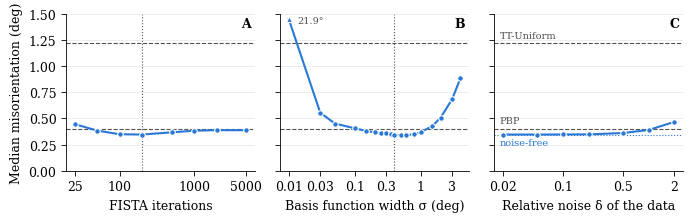

In [4]:
from matplotlib.ticker import FixedLocator, NullLocator

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.3), sharey=True)
panels = [("A", "iterations", axes[0], it, "FISTA iterations", NITER_USED),
          ("B", "sigma", axes[1], sg, "Basis function width σ (deg)", SIGMA_USED),
          ("C", "noise", axes[2], nz, "Relative noise δ of the data", None)]
for letter, key, ax, s, xlabel, used in panels:
    ax.set_gid(f"panel_{letter}_{key}")
    y = np.minimum(s.values, YMAX)
    off = s.values > YMAX  # off the scale: a triangle at the top edge, labelled with the value
    ax.plot(s.index, y, "-", color=COLOR, lw=1.5, zorder=3, gid=f"tt_adaptive_line_{letter}")
    ax.plot(s.index[~off], y[~off], "o", ms=4, color=COLOR, mec="white", mew=0.8, zorder=4, gid=f"tt_adaptive_points_{letter}")
    if off.any():
        ax.plot(s.index[off], y[off], "^", ms=5, color=COLOR, mec="white", mew=0.8, zorder=4, clip_on=False,
                gid=f"off_scale_point_{letter}")
    for x, v in zip(s.index[off], s.values[off]):
        ax.annotate(f"{v:.1f}°", (x, YMAX), xytext=(6, -1), textcoords="offset points", fontsize=7, color=REF,
                    va="center", gid=f"off_scale_label_{letter}")
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(TICKS[key]))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels([f"{t:g}" for t in TICKS[key]])
    ax.set_xlabel(xlabel)
    if used is not None:
        ax.axvline(used, color=REF, lw=0.8, ls=":", zorder=1, gid=f"used_setting_{letter}")
    for name in ("pbp", "tt_uniform"):
        ax.axhline(refs[name], color=REF, lw=0.8, ls="--", zorder=1, gid=f"{name}_line_{letter}")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e6e6e3", lw=0.5, zorder=0)
    ax.text(0.98, 0.98, letter, transform=ax.transAxes, fontweight="bold", va="top", ha="right",
            gid=f"panel_letter_{letter}")
axes[2].axhline(noise_free, color=COLOR, lw=0.8, ls=":", zorder=1, gid="noise_free_line_C")
x0 = axes[2].get_xlim()[0] * 1.15  # direct labels on the free left side of the right panel
axes[2].text(x0, noise_free - 0.03, "noise-free", fontsize=7, color=COLOR, va="top", gid="noise_free_label_C")
for name, label in (("pbp", "PBP"), ("tt_uniform", "TT-Uniform")):
    axes[2].text(x0, refs[name] + 0.03, label, fontsize=7, color=REF, va="bottom", gid=f"{name}_label_C")
axes[0].set_ylim(0, YMAX + 0.05)
axes[0].set_ylabel("Median misorientation (deg)")
fig.tight_layout(w_pad=0.8)
fig.savefig(f"{OUT}.svg", bbox_inches="tight")
fig.savefig(f"{OUT}.pdf", bbox_inches="tight")
fig.savefig(f"{OUT}.png", dpi=600, bbox_inches="tight")
print("saved", OUT + ".svg/.pdf/.png")
plt.show()